In [2]:
from typing import TypedDict,Dict,List
import random
from langgraph.graph import StateGraph, START, END  # noqa: F401

In [3]:
class AgentState(TypedDict):
    name: str
    number:List[int]
    counter:int
    

In [14]:
def greeting_node(state: AgentState) -> AgentState:
    """ Simple node that generates a greeting message. """
    state["name"] = f"Hello {state['name']}, how is your day?"
    state["counter"] = 0
    return state
def random_number_node(state: AgentState) -> AgentState:
    """ Node that generates a random number and adds it to the state. """
    state["number"].append(random.randint(1, 100))
    state["counter"] += 1
    return state
def should_continue_node(state: AgentState) -> str:
    """ Node that decides whether to continue generating random numbers. """
    if state["counter"] < 5:
        return "loop"
    else:
        return "exit"


In [15]:
graph=StateGraph(AgentState)
graph.add_node("greeting_node",greeting_node)
graph.add_node("random_number_node",random_number_node)
graph.add_edge(START,"greeting_node")
graph.add_edge("greeting_node","random_number_node")
graph.add_conditional_edges("random_number_node",should_continue_node,{"loop":"random_number_node","exit":END})
app=graph.compile()

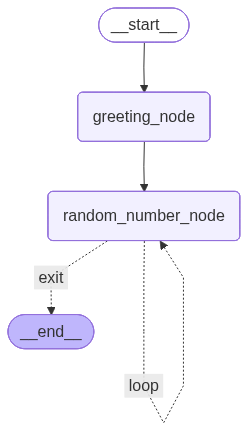

In [16]:
app

In [17]:
initial_state=AgentState(name="Alice",number=[],counter=0)

In [18]:
result=app.invoke(initial_state)